# 1. 데이터 준비

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
os.makedirs('/content/data', exist_ok=True)

!unzip -q "/content/drive/MyDrive/교통 공모전/생활이동_자치구_202607.zip" -d /content/data
!ls /content/data | head -5

__MACOSX
생활이동_자치구_202607


In [8]:
!cp "/content/drive/MyDrive/교통 공모전/(월) 평균매매가격_아파트.xlsx" /content/data/apt_price.xlsx
!cp "/content/drive/MyDrive/교통 공모전/서울생활이동데이터_자치구코드_20210907.xlsx" /content/data/gu_code.xlsx
!cp "/content/drive/MyDrive/교통 공모전/서울시 행정동별 대중교통 총 승차 승객수 정보.csv" /content/data/transit.csv

In [9]:
!pip install statsmodels scikit-learn seaborn -q

In [10]:
!ls -la /content/data

total 12952
drwxr-xr-x 4 root root     4096 Sep  5 08:31 .
drwxr-xr-x 1 root root     4096 Sep  5 08:31 ..
-rw------- 1 root root    14180 Sep  5 08:31 apt_price.xlsx
-rw------- 1 root root    15296 Sep  5 08:31 gu_code.xlsx
drwxr-xr-x 3 root root     4096 Sep  5 08:31 __MACOSX
-rw------- 1 root root 13212902 Sep  5 08:31 transit.csv
drwx------ 2 root root     4096 Sep  2 02:59 생활이동_자치구_202607


In [11]:
import os

data_dir = '/content/data'
for name in os.listdir(data_dir):
    full = os.path.join(data_dir, name)
    if name != '__MACOSX' and os.path.isdir(full):
        os.rename(full, os.path.join(data_dir, 'hourly'))
        print('renamed:', repr(name), '-> hourly')

renamed: '생활이동_자치구_202607' -> hourly


In [12]:
!ls /content/data/hourly | head -5

생활이동_자치구_2026.07_00시.csv
생활이동_자치구_2026.07_01시.csv
생활이동_자치구_2026.07_02시.csv
생활이동_자치구_2026.07_03시.csv
생활이동_자치구_2026.07_04시.csv


In [13]:
commute_time_by_gu = load_living_migration(f"{DATA_DIR}/hourly/*.csv")

24개 파일 로드


# 2. 1차 데이터 분석

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 한글 폰트 (코랩 기본 환경엔 나눔고딕 없어서 설치)
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = "/content/data"

# ---------- PART 1. 자치구 코드 ----------
def load_gu_code(path=f"{DATA_DIR}/gu_code.xlsx"):
    gu_code = pd.read_excel(path, sheet_name="Sheet1")
    gu_code.columns = ["시도코드", "시군구코드", "구명", "전체명"]
    gu_code["시군구코드"] = gu_code["시군구코드"].astype(str)
    return gu_code

# ---------- PART 2. 아파트 매매가 ----------
def load_apt_price(path=f"{DATA_DIR}/apt_price.xlsx"):
    raw = pd.read_excel(path, sheet_name="excel", header=0, skiprows=[1])
    raw.columns = ["No", "시도", "권역", "생활권", "구"] + list(raw.columns[5:])
    raw = raw[raw["시도"] == "서울"].copy()
    raw = raw[raw["구"].astype(str).str.endswith("구")]
    month_cols = [c for c in raw.columns if "년" in str(c)]
    long_df = raw.melt(id_vars=["구"], value_vars=month_cols,
                        var_name="기준월", value_name="평균매매가_천원")
    long_df["평균매매가_천원"] = pd.to_numeric(long_df["평균매매가_천원"], errors="coerce")
    return long_df

# ---------- PART 3. 대중교통 승차 ----------
def load_transit(path=f"{DATA_DIR}/transit.csv", gu_code=None):
    df = pd.read_csv(path, encoding="cp949", dtype={"행정동_ID": str})
    df["시군구코드"] = df["행정동_ID"].str[:5]
    df = df.merge(gu_code[["시군구코드", "구명"]], on="시군구코드", how="left")
    df["기준월"] = df["기준_날짜"].astype(str).str[:6]
    rush_cols = ["승객_수_07시", "승객_수_08시", "승객_수_09시"]
    df["출근시간대_승객수"] = df[rush_cols].sum(axis=1)
    gu_month = df.groupby(["구명", "기준월"]).agg(
        총승객수=("승객_수", "sum"),
        출근시간대_승객수=("출근시간대_승객수", "sum"),
    ).reset_index()
    gu_month["출근집중도"] = gu_month["출근시간대_승객수"] / gu_month["총승객수"]
    return gu_month

# ---------- PART 4. 생활이동 (24개 시간대 파일) ----------
def load_living_migration(pattern, weekday_only=True, seoul_only=True):
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise FileNotFoundError(f"'{pattern}' 패턴에 맞는 파일이 없습니다.")
    print(f"{len(paths)}개 파일 로드")

    usecols = ["대상연월", "요일", "도착시간", "출발 시군구 코드", "도착 시군구 코드",
               "이동유형", "평균 이동 시간(분)", "이동인구(합)"]
    dtype = {"출발 시군구 코드": str, "도착 시군구 코드": str, "이동유형": str, "요일": str}

    dfs = []
    for p in paths:
        tmp = pd.read_csv(p, encoding="cp949", usecols=usecols, dtype=dtype)
        tmp = tmp[tmp["이동유형"] == "HW"]
        if weekday_only:
            tmp = tmp[tmp["요일"].isin(["월", "화", "수", "목", "금"])]
        if seoul_only:
            tmp = tmp[tmp["출발 시군구 코드"].str.startswith("11")]
        dfs.append(tmp)
    df = pd.concat(dfs, ignore_index=True)
    df["이동인구(합)"] = pd.to_numeric(df["이동인구(합)"], errors="coerce")

    def weighted_avg(group):
        w = group["이동인구(합)"]
        v = group["평균 이동 시간(분)"]
        mask = w.notna() & v.notna()
        if mask.sum() == 0:
            return np.nan
        return np.average(v[mask], weights=w[mask])

    commute_time_by_gu = (
        df.groupby("출발 시군구 코드")
        .apply(weighted_avg, include_groups=False)
        .reset_index(name="평균통근시간_분")
        .rename(columns={"출발 시군구 코드": "시군구코드"})
    )
    return commute_time_by_gu

# ---------- PART 5. 병합 ----------
def build_master_table(price_long, transit_gu_month, commute_time_by_gu, gu_code,
                        price_month="2026년 7월", transit_month="202607"):
    price_latest = price_long[price_long["기준월"] == price_month][["구", "평균매매가_천원"]]
    transit_latest = transit_gu_month[transit_gu_month["기준월"] == transit_month]
    master = transit_latest.merge(price_latest, left_on="구명", right_on="구", how="inner")
    commute_named = commute_time_by_gu.merge(gu_code[["시군구코드", "구명"]], on="시군구코드", how="left")
    master = master.merge(commute_named[["구명", "평균통근시간_분"]], on="구명", how="left")
    return master

# ---------- PART 6. 회귀분석 ----------
def analyze(master):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=master, x="평균매매가_천원", y="평균통근시간_분", ax=ax)
    for _, row in master.iterrows():
        ax.annotate(row["구명"], (row["평균매매가_천원"], row["평균통근시간_분"]), fontsize=8)
    ax.set_title("자치구 평균 아파트 매매가 vs 평균 통근시간")
    plt.tight_layout()
    plt.savefig("price_vs_commute.png", dpi=150)
    plt.show()

    X = sm.add_constant(master["평균매매가_천원"])
    y = master["평균통근시간_분"]
    model = sm.OLS(y, X, missing="drop").fit()
    print(model.summary())

    master["예측통근시간"] = model.predict(X)
    master["잔차"] = master["평균통근시간_분"] - master["예측통근시간"]
    print("\n[통근부담이 예상보다 훨씬 큰 자치구 TOP 5]")
    print(master.sort_values("잔차", ascending=False)[["구명", "평균매매가_천원", "평균통근시간_분", "잔차"]].head(5))
    return master, model

# ---------- PART 7. 군집분석 ----------
def cluster_gu(master, n_clusters=4):
    feats = master[["평균매매가_천원", "평균통근시간_분", "출근집중도"]].dropna()
    scaled = StandardScaler().fit_transform(feats)
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    feats["cluster"] = km.fit_predict(scaled)
    result = master.loc[feats.index].copy()
    result["cluster"] = feats["cluster"]
    summary = result.groupby("cluster")[["평균매매가_천원", "평균통근시간_분", "출근집중도"]].mean()
    print(summary)
    return result, summary

# ---------- 실행 ----------
gu_code = load_gu_code()
price_long = load_apt_price()
transit_gu_month = load_transit(gu_code=gu_code)
commute_time_by_gu = load_living_migration(f"{DATA_DIR}/hourly/*.csv")

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


24개 파일 로드


## 2-1. 대중교통 + 집값 + 통근시간 병합 테이블

1. 목적
- 서로 다른 출처의 데이터를 통합

2. 도출 방법
- 대중교통 CSV(원래는 행정동 단위, 일별)를 자치구코드로 매핑한 뒤 자치구·월 단위로 groupby 집계 → 총승객수, 출근시간대(7~9시) 승객수 합산
- 출근집중도 = 출근시간대_승객수 / 총승객수 계산 → "이 구에서 하루 대중교통 이용 중 몇 %가 출근시간대에 몰리는가"를 나타내는 비율 변수
- 이렇게 만든 표를 구명 기준으로 아파트 가격표, 생활이동 통근시간표와 각각 merge
- 25개 자치구 × (총승객수, 출근집중도, 평균매매가, 평균통근시간) 형태의 표 완성

3. 결과
- 총승객수는 자치구 규모(인구·상업밀도) 영향을 크게 받음 강남구(2,857만)·중구(2,050만)처럼 업무지구가 몰린 곳이 압도적으로 높고, 이건 "거주자 수"가 아니라 "그 자치구를 지나가는 통행량" 개념에 가까움
- 출근집중도 내 대비 : 중랑구(0.279)·은평구(0.279)·관악구(0.269)처럼 주거 중심 외곽 지역일수록 출근집중도가 높고, 종로구(0.092)·중구(0.103)·강남구(0.138)처럼 업무 중심지일수록 낮음 업무지구는 하루 종일 유동인구가 있어서 출근시간대 비중이 상대적으로 희석되는 것

4. 인사이트
- 출근집중도가 높은 구(중랑·은평·관악·강서·중구 반대편)일수록 대체로 통근시간도 긴 편(관악 61.8분, 중랑 53.4분, 은평 59.1분) : "이 지역 주민들이 대중교통을 탈 때 특정 시간대(러시아워)에 쏠려서 타야 하는 상황"과 "그럼에도 오래 걸린다"가 겹쳐 있음

In [16]:
# ---------- PART 5. 병합 ----------
def build_master_table(price_long, transit_gu_month, commute_time_by_gu, gu_code,
                        price_month="2026년 7월", transit_month="202607"):
    price_latest = price_long[price_long["기준월"] == price_month][["구", "평균매매가_천원"]]
    transit_latest = transit_gu_month[transit_gu_month["기준월"] == transit_month]
    master = transit_latest.merge(price_latest, left_on="구명", right_on="구", how="inner")
    commute_named = commute_time_by_gu.merge(gu_code[["시군구코드", "구명"]], on="시군구코드", how="left")
    master = master.merge(commute_named[["구명", "평균통근시간_분"]], on="구명", how="left")
    return master

# ---------- 실행 ----------
master = build_master_table(price_long, transit_gu_month, commute_time_by_gu, gu_code)
print(master.sort_values("평균통근시간_분", ascending=False))

      구명     기준월        총승객수  출근시간대_승객수     출근집중도     구  평균매매가_천원   평균통근시간_분
19  영등포구  202607  16398967.0  3129319.0  0.190824  영등포구   1403556  62.819623
4    관악구  202607  16458626.0  4423702.0  0.268777   관악구    794198  61.751878
7    금천구  202607   6075990.0  1332056.0  0.219233   금천구    628836  61.742228
21   은평구  202607  10615169.0  2958331.0  0.278689   은평구    824238  59.080952
3    강서구  202607  10756573.0  2715089.0  0.252412   강서구    931790  58.622279
13  서대문구  202607   9806231.0  1964269.0  0.200308  서대문구    997642  57.613753
1    강동구  202607   8879156.0  2391828.0  0.269376   강동구   1217737  57.434969
6    구로구  202607  11245758.0  2895354.0  0.257462   구로구    731055  56.821568
8    노원구  202607  10001346.0  2570049.0  0.256970   노원구    686472  56.341753
17   송파구  202607  17687937.0  3791187.0  0.214337   송파구   2378512  54.809463
0    강남구  202607  28574849.0  3956676.0  0.138467   강남구   2880629  54.637811
14   서초구  202607  20611529.0  3243125.0  0.157345   서초구   2859491  54.347942

## 2-2. 산점도 : 집값 vs 통근시간
1. 목적
- "집값이 낮은 자치구일수록 통근시간이 길다"는 원래 가설을 눈으로 먼저 확인하기 위함. 회귀분석 전에 항상 산점도를 먼저 봐야 데이터의 실제 모양(선형인지, 군집이 있는지)을 알 수 있음.

2. 도출 방법
- x축: 자치구별 아파트 평균매매가(2026.07, 부동산원 시계열)
- y축: 자치구별 평균 통근시간(생활이동데이터에서 HW형 이동만 필터링해 이동인구로 가중평균)
- 두 값을 자치구명으로 병합(merge)해서 25개 점을 찍음

3. 결과
- 점들이 왼쪽 위(저가+장통근)에도 몰려있고, 오른쪽 위(고가+장통근)에도 몰려있고, 가운데 아래(중가+단통근)에도 몰려있음 -> 일직선으로 떨어지는 게 아니라 U자에 가까운 비선형 패턴
- 저가+장통근 (왼쪽 위): 관악구, 금천구, 은평구, 강서구, 노원구, 구로구, 강북구, 도봉구, 중랑구 — 집값 0.6-0.9M대인데 통근시간 55-62분. -> 원래 가정한 "이중고" 지역

- 중가+최단통근 (오른쪽 아래): 종로구, 중구, 용산구, 성동구 — 집값이 중간-높은데 통근시간이 오히려 제일 짧음(43-48분). 이 지역들은 도심 자체이거나 도심에 바로 붙어있어서, 여기 사는 사람들이 여기서 일할 확률이 높기 때문일 것으로 예상.

- 고가인데 통근도 긴 편 (오른쪽 위): 강남구, 서초구, 송파구 — 집값 최상위인데 통근시간이 54-55분으로 짧지 않음. 아마 강남 3구는 직주근접이 아니라 오히려 "출발지"보다 "목적지"(직장 밀집지) 성격이 강해서, 여기 거주자 중 다른 업무지구로 역통근하는 사람들이 섞여있거나, 대형 업무지구라 원거리 통근자를 많이 흡수하는 구조일 수 있음.

4. 인사이트
- 단순히 "가격이 낮다=통근이 길다"가 아니라, 집값과 통근시간을 동시에 결정하는 제3의 변수(위치, 즉 도심으로부터의 거리)가 있을 가능성을 시사함




## 2-3. 1차 회귀분석 : 통근시간 ~ 집값
1. 목적
- 산점도에서 본 패턴이 "우연"이 아니라 통계적으로 의미 있는 관계인지 검정하기 위함.

2. 도출 방법
- statsmodels.OLS(최소제곱 선형회귀)로 종속변수(통근시간_분)를 독립변수(평균매매가) 하나로 설명하는 모델을 적합
- y = β₀ + β₁ * 집값 + 오차 형태

3. 결과
- R square = 0.056 : 유의하지 않음
- p-value = 0.256 : 유의하지 않음
- "집값이 낮을수록 통근시간이 길다"는 단순한 선형관계는 통계적으로 뒷받침되지 않음
- 표본이 25개(자치구 수)로 작아서라고도 볼 수 있으나 폐기. (행정동으로 하면 표본 수를 늘릴 수는 있음)

4. 인사이트
- 기존 가설이었던 집값→통근격차는 이 데이터만으로는 입증되지 않음

## 2-4. 통근부담이 예상보다 훨씬 큰 자치구 TOP 5
1. 목적
- 회귀선 자체는 약했지만, 그래도 "회귀선 대비 유독 튀는 지역"이 있는지, 그리고 자치구들을 비슷한 특성끼리 묶었을 때 어떤 그룹이 나오는지 보기 위함.
- 1차 모델의 잔차 상위 5개 + 군집분석

2. 도출 방법
- 잔차 = 실제 통근시간 − 회귀모델이 예측한 통근시간
- 잔차가 크다는 건 "이 정도 집값이면 이 정도 통근시간이 나와야 하는데, 실제로는 그보다 훨씬 오래 걸린다"는 뜻
- K-means 군집분석: 집값·통근시간·출근집중도 3개 변수를 표준화한 뒤, 비슷한 자치구끼리 4개 그룹으로 자동 분류

3. 결과
- 영등포·관악·금천·은평·강서는 회귀모델 예측보다 최대 8.7분 더 오래 걸리는 지역
- 군집 요약표를 보면 cluster3(집값 114만원, 통근 44.8분)이 유독 짧고, cluster2(집값 97만원, 통근 59.9분)가 유독 김 → 비슷한 집값대인데 통근시간은 정반대인 두 그룹이 존재

4. 인사이트
- 1차 회귀모델(집값만 사용)로는 못 잡아낸 세부 그룹 차이가 군집분석에서 드러남
- 집값이 비슷해도 위치에 따라 통근시간이 극단적으로 갈린다"는 게 여기서 처음 포착됐고, 이게 "도심거리"라는 변수를 추가해야겠다는 결정으로 이어짐

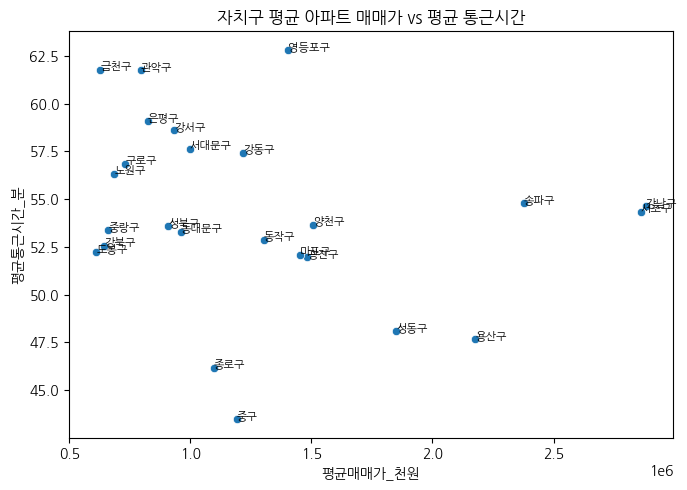

                            OLS Regression Results                            
Dep. Variable:               평균통근시간_분   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.359
Date:                Sat, 05 Sep 2026   Prob (F-statistic):              0.256
Time:                        08:36:35   Log-Likelihood:                -73.271
No. Observations:                  25   AIC:                             150.5
Df Residuals:                      23   BIC:                             153.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.4474      2.081     27.120      0.0

In [20]:
# ---------- PART 6. 회귀분석 ----------
def analyze(master):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=master, x="평균매매가_천원", y="평균통근시간_분", ax=ax)
    for _, row in master.iterrows():
        ax.annotate(row["구명"], (row["평균매매가_천원"], row["평균통근시간_분"]), fontsize=8)
    ax.set_title("자치구 평균 아파트 매매가 vs 평균 통근시간")
    plt.tight_layout()
    plt.savefig("price_vs_commute.png", dpi=150)
    plt.show()

    X = sm.add_constant(master["평균매매가_천원"])
    y = master["평균통근시간_분"]
    model = sm.OLS(y, X, missing="drop").fit()
    print(model.summary())

    master["예측통근시간"] = model.predict(X)
    master["잔차"] = master["평균통근시간_분"] - master["예측통근시간"]
    print("\n[통근부담이 예상보다 훨씬 큰 자치구 TOP 5]")
    print(master.sort_values("잔차", ascending=False)[["구명", "평균매매가_천원", "평균통근시간_분", "잔차"]].head(5))
    return master, model

# ---------- 실행 ----------
master, model = analyze(master)

In [19]:
# ---------- PART 7. 군집분석 ----------
def cluster_gu(master, n_clusters=4):
    feats = master[["평균매매가_천원", "평균통근시간_분", "출근집중도"]].dropna()
    scaled = StandardScaler().fit_transform(feats)
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    feats["cluster"] = km.fit_predict(scaled)
    result = master.loc[feats.index].copy()
    result["cluster"] = feats["cluster"]
    summary = result.groupby("cluster")[["평균매매가_천원", "평균통근시간_분", "출근집중도"]].mean()
    print(summary)
    return result, summary

# ---------- 실행 ----------
result, summary = cluster_gu(master)

             평균매매가_천원   평균통근시간_분     출근집중도
cluster                                   
0        9.493894e+05  53.676387  0.251000
1        2.266746e+06  51.941593  0.173777
2        9.711424e+05  59.866526  0.239946
3        1.144488e+06  44.829979  0.097674


# 3. 2차 데이터 분석 _ 피봇팅

In [ ]:
print(result[['구명', 'cluster']].sort_values('cluster').to_string(index=False))

  구명  cluster
 강북구        0
 광진구        0
 구로구        0
 노원구        0
 동작구        0
동대문구        0
 도봉구        0
 성북구        0
 양천구        0
 중랑구        0
 마포구        1
 용산구        1
 송파구        1
 서초구        1
 성동구        1
 강남구        1
서대문구        2
 강동구        2
 관악구        2
 금천구        2
 강서구        2
영등포구        2
 은평구        2
 종로구        3
  중구        3


## 3-1. 2차 회귀분석 : 통근시간 ~ 집값+도심거리
1. 목적
- 앞서 발견한 "위치 효과"를 정식 변수로 넣어서, 집값의 순수한 효과가 남아있는지 재검증하기 위함.

2. 도출 방법
- 각 구청 좌표와 서울시청 좌표 사이의 하버사인(haversine) 직선거리를 계산해 도심거리_km 변수 생성
- 통근시간 ~ 집값 + 도심거리 다중회귀(multiple regression) 적합

3. 결과
- R square=0.376 -> 설명력 5.6%에서 크게 상승
- 도심거리_km 계수 = 0.71, p = 0.003(유의): 도심에서 1km 멀어질 때마다 통근시간이 평균 0.71분씩 늘어나며, 이건 우연이 아니라고 통계적으로 확신할 수 있음
- 집값 계수는 여전히 p = 0.292(비유의): 도심거리를 통제하고 나면 집값 자체는 설명력이 없음

4. 인사이트
- 집값과 통근시간의 겉보기 상관관계는 사실 둘 다 "도심거리"라는 공통 원인 때문에 생긴 가짜 상관(spurious correlation)임
- 혼란변수(confounding variable)를 통제했더니 원래 변수의 효과가 사라짐
- "집값이 싸서 불리하다"가 아니라 "도심에서 멀어서 집값도 싸고 통근도 길다"는 게 정확한 인과구조

In [ ]:
from math import radians, sin, cos, sqrt, atan2

# 25개 구청 대략 좌표 (구청 기준)
gu_coords = {
    '종로구': (37.5730, 126.9794), '중구': (37.5641, 126.9979), '용산구': (37.5326, 126.9906),
    '성동구': (37.5633, 127.0371), '광진구': (37.5384, 127.0822), '동대문구': (37.5744, 127.0396),
    '중랑구': (37.6063, 127.0925), '성북구': (37.5894, 127.0167), '강북구': (37.6396, 127.0257),
    '도봉구': (37.6688, 127.0471), '노원구': (37.6542, 127.0568), '은평구': (37.6027, 126.9291),
    '서대문구': (37.5791, 126.9368), '마포구': (37.5663, 126.9019), '양천구': (37.5169, 126.8664),
    '강서구': (37.5509, 126.8495), '구로구': (37.4954, 126.8874), '금천구': (37.4519, 126.9020),
    '영등포구': (37.5264, 126.8963), '동작구': (37.5124, 126.9393), '관악구': (37.4784, 126.9516),
    '서초구': (37.4837, 127.0324), '강남구': (37.5172, 127.0473), '송파구': (37.5145, 127.1059),
    '강동구': (37.5301, 127.1238),
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

city_hall = (37.5665, 126.9780)  # 서울시청
master['도심거리_km'] = master['구명'].map(
    lambda g: haversine(*gu_coords[g], *city_hall) if g in gu_coords else np.nan
)

# 다중회귀: 통근시간 ~ 집값 + 도심거리
X2 = sm.add_constant(master[['평균매매가_천원', '도심거리_km']])
y2 = master['평균통근시간_분']
model2 = sm.OLS(y2, X2, missing='drop').fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               평균통근시간_분   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     6.629
Date:                Wed, 02 Sep 2026   Prob (F-statistic):            0.00558
Time:                        03:54:45   Log-Likelihood:                -68.093
No. Observations:                  25   AIC:                             142.2
Df Residuals:                      22   BIC:                             145.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.9203      2.601     19.191      0.0

## 3-2. 2차 모델의 잔차 전체 테이블
1. 목적
- "도심거리로 다 설명되는 게 아니라, 거리를 감안해도 유독 통근이 긴 지역"을 정확히 특정하기 위함
- 정책 타겟 뽑기
2. 도출 방법
- 2차 모델의 예측값을 구하고, 실제 통근시간에서 뺀 잔차2를 자치구별로 정렬
- 이 중 집값도 낮은 지역만 교차 확인(순수 인프라 문제 vs 단순 부촌효과 구분 위해)
3. 결과
- 잔차2가 큰 순서: 영등포(+8.7) > 서대문(+6.2) > 은평(+6.0) > 관악(+5.7) > 강남(+2.6) > 금천(+2.3) > 강서(+1.7)
- 강남·서초도 양수 잔차(거리 대비 예상보다 김)인데, 이 두 곳은 집값이 최상위라 "이동격차"의 정책 타겟으로 삼기엔 성격이 다름
- 도봉(-6.1), 중구(-6.2)는 거리 대비 예상보다 훨씬 짧음 → 벤치마크 대상
4. 인사이트
- 집값도 낮고 잔차도 큰 은평구·관악구·금천구·강서구가 최종 타겟으로 좁혀짐 -> 이 지역들은 "도심에서 먼 것만으로 설명되지 않는, 순수하게 대중교통 공급 자체가 부족한" 곳일 가능성이 높음

In [ ]:
master['예측통근시간2'] = model2.predict(X2)
master['잔차2'] = master['평균통근시간_분'] - master['예측통근시간2']

print(master.sort_values('잔차2', ascending=False)
      [['구명', '도심거리_km', '평균매매가_천원', '평균통근시간_분', '잔차2']]
      .to_string(index=False))

  구명   도심거리_km  평균매매가_천원  평균통근시간_분       잔차2
영등포구  8.471288   1403556 62.819623  8.669208
서대문구  3.891919    997642 57.613753  6.208414
 은평구  5.896559    824238 59.080952  6.017773
 관악구 10.069141    794198 61.751878  5.667893
 강남구  8.208742   2880629 54.637811  2.594142
 금천구 14.398661    628836 61.742228  2.349466
 성북구  4.256169    907715 53.595494  1.813018
 강서구 11.459003    931790 58.622279  1.723853
 서초구 10.381841   2859491 54.347942  0.723886
동대문구  5.499636    959333 53.306779  0.702772
 구로구 11.239681    731055 56.821568 -0.180939
 동작구  6.915997   1304190 52.882665 -0.285425
 강동구 13.475891   1217737 57.434969 -0.533225
 마포구  6.707366   1453991 52.091779 -0.732588
 송파구 12.672790   2378512 54.809463 -1.076657
 노원구 11.969870    686472 56.341753 -1.240481
 용산구  3.929765   2177533 47.678939 -2.220441
 양천구 11.279803   1506488 53.663530 -2.360145
 종로구  0.733224   1098145 46.183378 -2.834140
 광진구  9.702615   1482803 51.965646 -2.961726
 강북구  9.150298    643136 52.563853 -3.059787
 성동구  5.22

# 4. 결론 _ 정책 제안

### <왜 도봉구는 되고 관악구·은평구는 안 되는가>


| 구 | 도심거리 | 실제 통근시간 | 잔차2(거리로 예측한 값과의 차이) |
|---|---|---|---|
| 도봉구 | 12.90km (더 멀다) | 52.23분 | **-6.12분** (예상보다 훨씬 짧음) |
| 강북구 | 9.15km | 52.56분 | -3.06분 |
| 은평구 | 5.90km (더 가깝다) | 59.08분 | **+6.02분** (예상보다 훨씬 김) |
| 관악구 | 10.07km | 61.75분 | +5.67분 |

- 은평구가 관악구보다 도심에서 더 가까운데도 통근시간은 더 긺
- "거리"만으로는 절대 설명이 안 되는 역전 현상 -> 순수하게 "노선 구조"의 문제가 아님

- 추정되는 구조적 원인
  - 도봉구·강북구: 1호선·4호선이 도심(종로·시청)까지 큰 환승 없이 비교적 직선으로 연결돼요. 거리는 멀어도 "직결 노선"이라 체감 시간이 짧아요.
  - 관악구: 2022년 신림선이 개통되기 전까지는 2호선 하나뿐이었어요. 2호선은 순환선이라 도심 한복판(종로·시청)으로 바로 가지 않고 우회하거나 환승이 필요해요. 신림선도 2호선으로 갈아타는 걸 도와줄 뿐, 도심 직결 노선은 아니에요.
  - 은평구: 3호선·6호선이 있지만, 3호선은 구파발·연신내에서 도심까지 정차역이 많아 시간이 걸리고, 6호선은 도심 핵심부를 직접 관통하지 않아요. 게다가 지형이 넓고 구릉지가 많아 지하철역까지 버스로 이동해야 하는 구간이 많아요.

- 즉 "직결 노선의 유무"가 거리보다 통근시간을 더 크게 좌우한다는 게 이 대조의 결론이에요. 이건 지난번 확인한 정성적 사실(서울시가 은평~관악 축을 "교통 소외지역"으로 공식 지정하고 서부선을 추진 중)과도 정확히 맞아떨어져요.

---

### <최종 정책 제안>

- 정책 타겟 우선순위

| 순위 | 자치구 | 근거 |
|---|---|---|
| 1 | 은평구 | 도심 최근접권임에도 초과통근 2위(+6.0분), 직결노선 부재 |
| 2 | 관악구 | 초과통근 3위(+5.7분)이면서 2022년 이전 단일노선 취약사 확인 |
| 3 | 금천구 | 초과통근(+2.3분) + 최저 집값권 → 저소득층 이동격차 성격 뚜렷 |
| 4 | 강서구 | 초과통근(+1.7분), 9호선 있으나 급행 배차 등 개선 여지 |

*(참고: 강남·서초도 잔차는 양수였지만 최고가 지역이라 "이동격차" 정책의 형평성 타겟과는 성격이 달라 제외)*

- 정책 A. 단기 - 노선 신설 전 과도기 대책 (즉시 시행 가능)

  - 광역·간선급행버스(BRT) 신설: 은평구(연신내·구파발)와 관악구(신림·서울대입구)에서 도심 방향으로 무정차에 가까운 급행버스 노선 신설. 신규 지하철 개통까지 최소 5~10년이 걸리는 만큼, 이 공백을 메우는 게 우선.
  - 환승저항 완화: 2호선·3호선·6호선 환승역(신림, 연신내 등)에 환승 대기시간을 줄이는 환승센터·에스컬레이터 등 편의시설 우선 개선.
  - 탄력 배차: 출근집중도가 높게 나온(관악 0.269, 은평 0.279) 지역 특성을 반영해, 러시아워 시간대 배차간격을 더 촘촘히 조정.

- 정책 B. 중기 — 신규 노선의 우선순위 재확인

  - 이미 계획된 서부선(은평~관악 등 6개 구 연결)과 금천구 서남선의 예비타당성·착공 순위 심사에 본 분석의 "초과 통근시간" 지표를 정량적 근거자료로 제출.
  - "단순히 인구가 많아서"가 아니라 "거리 대비 이동격차가 데이터로 입증된 지역"이라는 논리로 우선순위를 강화할 수 있음

- 정책 C. 장기 — 구조적 접근

  - 관악구·은평구처럼 노선 자체가 순환·비직결 구조인 지역은, 노선을 새로 놓는 것 외에도 도심 접근성이 높은 부도심(예: 마곡, 상암)으로 일자리를 분산 배치하는 도시계획적 접근을 병행 검토. 노선 신설만으로는 근본적 해결에 한계가 있을 수 있음을 보고서에 언급.

### <기대효과>

- 은평·관악 거주 통근자가 초과통근시간(각 6.0분, 5.7분)을 해소할 경우, 왕복 기준 1인당 연간 약 40~44시간(출근일수 220일 기준)의 이동시간이 절감

---

### <한계점>

- 도봉구 vs 관악구·은평구 비교는 노선 구조에 대한 정성적 추론이며, 실제 환승 횟수·소요시간 데이터로 검증한 것은 아님 → "후속 분석 과제"로 명시
- 표본이 25개 구로 작아 통계적 결론의 일반화에는 신중해야 함
- 생활이동데이터는 통신 신호 기반 추정치임